# YIN pitch estimation algorithm
Python implementation of the YIN algorithm described on [this paper](http://audition.ens.fr/adc/pdf/2002_JASA_YIN.pdf). 

In [29]:
! pip install numpy scipy matplotlib tqdm IPython sounddevice soundfile

  Using cached cffi-2.0.0-cp314-cp314-win_amd64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 7.9 MB/s  0:00:00
Using cached cffi-2.0.0-cp314-cp314-win_amd64.whl (185 kB)
Using cached pycparser-3.0-py3-none-any.whl (48 kB)

   ---------------------------------------- 0/4 [pycparser]
   ---------------------------------------- 0/4 [pycparser]
   ---------------------------------------- 0/4 [pycparser]
   ---------------------------------------- 0/4 [pycparser]
   ---------- ----------------------------- 1/4 [cffi]
   ---------- ----------------------------- 1/4 [cffi]
   ---------- ----------------------------- 1/4 [cffi]
   ---------- ----------------------------- 1/4 [cffi]
   ---------- ----------------------------- 1/4 [cffi]
   ---------- ----------------------------- 1/4 [cffi]
   ---------- ----------------------------

In [ ]:
from scipy import signal as sg
from scipy.io import wavfile
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sounddevice as sd
import soundfile as sf

In [1]:
# Record audio using sounddevice and save as WAV, while playing a song
duration = 5  # Duration of recording in seconds (adjust as needed)
fs = 44100  # Sampling rate (standard for audio)

# Volume controls for mixed playback (adjust these values: 0.0 to 1.0)
song_volume = 0.3  # Reduce song volume (e.g., 0.3 for quieter)
rec_volume = 1.0   # Recording volume (e.g., 1.0 for full)

# Load the song to play during recording
fs_song, song = sf.read('Sounds/427200__thescarlettwitch89__female-ooh-singing-voice-cleaned-with-reverb-by-erokia.wav')
if song.ndim > 1:
    song = song[:, 0]  # Convert to mono if stereo

# Resample song to match recording sample rate for proper playback
song_resampled = sg.resample(song, int(len(song) * fs / fs_song)) # how does this convert the song to the new sample rate? It uses scipy's resample function, which changes the number of samples in the song according to the ratio of the new sample rate (fs) to the original sample rate (fs_song). The length of the resampled song is calculated as int(len(song) * fs / fs_song), which ensures that the duration of the song remains the same while adjusting for the new sample rate.
songaudio = song_resampled[:int(duration * fs)]  # How  does this Trim to match recording duration? It trims the resampled song to match the duration of the recording by taking only the first int(duration * fs) samples, which corresponds to the number of samples in the recording duration at the given sample rate (fs).
print("Recording for", duration, "seconds... Speak into your microphone while the song plays.")
# Play the song
sd.play(songaudio, fs)
# Record simultaneously
recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)  # Record mono audio
sd.wait()  # Wait for both playback and recording to finish
sf.write('Sounds/recorded_audio.wav', recording, fs)  # Save recording as WAV file
print("Recording saved as 'Sounds/recorded_audio.wav'")

# Plot both signals side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot recorded audio
ax1.plot(np.arange(len(recording)) / fs, recording.flatten())
ax1.set_xlim(0, len(recording) / fs)
ax1.grid(True)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Recorded Audio Signal')

# Plot song audio
ax2.plot(np.arange(len(songaudio)) / fs, songaudio)
ax2.set_xlim(0, len(songaudio) / fs)
ax2.grid(True)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')
ax2.set_title('Song Audio Signal (Played)')

plt.tight_layout()
plt.show()

# Mixed playback: hear both recorded audio and song together with adjustable volumes
mixed_audio = (rec_volume * recording.flatten() + song_volume * songaudio) / 2  # Apply volumes and average to mix without clipping
print("Mixed Playback (Recorded + Song) - Adjust volumes in code if needed:")
ipd.Audio(mixed_audio, rate=fs)

NameError: name 'sf' is not defined

In [49]:
import sounddevice as sd
print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone Array (Intel® Smart , MME (6 in, 0 out)
   2 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  3 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   4 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   5 Microphone Array (Intel® Smart Sound Technology for Digital Microphones), Windows DirectSound (6 in, 0 out)
   6 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
   7 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
   8 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
   9 Microphone Array (Intel® Smart Sound Technology for Digital Microphones), Windows WASAPI (4 in, 0 out)
  10 Stereo Mix (Realtek HD Audio Stereo input), Windows WDM-KS (2 in, 0 out)
  11 Speakers 1 (Realtek HD Audio output with SST), Windows WDM-KS (0 in, 2 out)
  12 Speakers 2 (Realtek HD Audio output with SST), Windows WDM-KS (0 in, 2 out)
  13 PC Speaker (Realtek HD Audio output with SST), Windows

These are some functions that we are going to need later.

In [39]:
# This function takes in an array and finds the first local minima below a given threshold.
def find_first_local_min_below_threshold(array, threshold):
  local_minima_indices = sg.argrelmin(array)[0]
  for idx in local_minima_indices:
      if array[idx] < threshold:
          return idx
  return None

In [40]:
# This function performs the parabolic interpolation to find the exact x position of the local minima.
def parabolic_interp(prev, max, next):
    numerator = prev - next
    denominator = prev - 2 * max + next
    
    x_max = 0.5 * numerator / denominator
    
    return x_max

To test the algorithm I use [this sound](https://freesound.org/people/TheScarlettWitch89/sounds/427200/) from [freesound](https://freesound.org/).

In [41]:
# Load the audio file and convert it to mono.
fs, audio = wavfile.read('Sounds/recorded_audio.wav') # Change this to the path of your audio file.
if audio.ndim > 1: # If the audio has more than one channel, take only the first channel (mono).
    audio = audio[:, 0] # Take the first channel (mono).

This is what the input audio signal looks and sounds like:

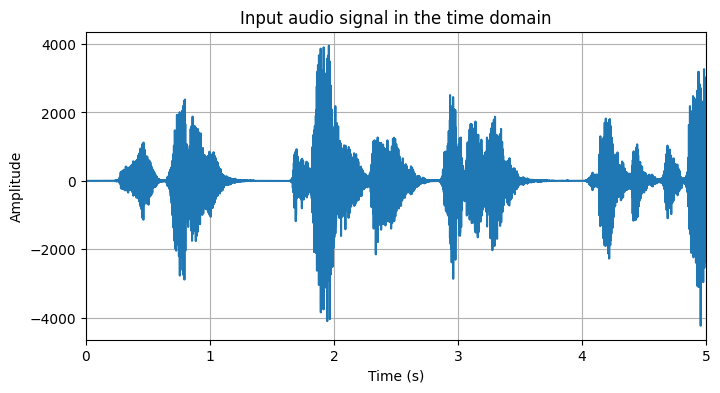

In [42]:
# Plot the audio file
plt.figure(figsize=(8, 4)) # Set the figure size to 8 inches wide and 4 inches tall
plt.plot(np.arange(len(audio))/fs, audio) # Plot the audio signal against time in seconds
plt.xlim(0, len(audio)/fs) # Set the x-axis limits to the duration of the audio signal
plt.grid(True) # Add a grid to the plot for better visibility

plt.xlabel('Time (s)') # Set the x-axis label to "Time (s)"
plt.ylabel('Amplitude') # Set the y-axis label to "Amplitude"
plt.title('Input audio signal in the time domain') # Set the title of the plot to "Input audio signal in the time domain"
plt.show() # Display the plot

ipd.Audio(audio, rate=fs) # Play the audio signal using IPython's Audio function, specifying the sample rate (fs) for correct playback speed.

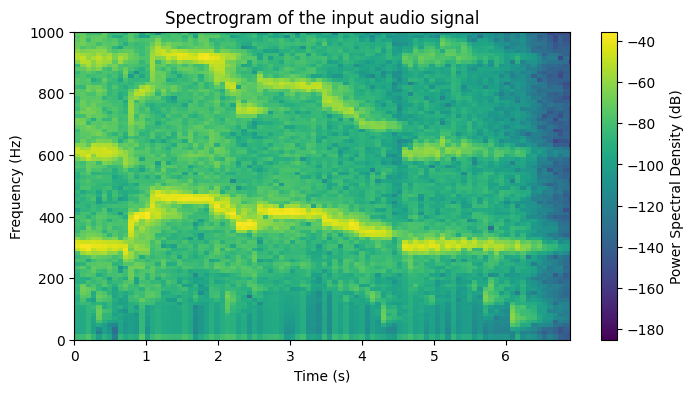

In [7]:
W = 2**12 # Set the window size for the spectrogram to 4096 samples (2^12), which is a common choice for audio analysis as it provides a good balance between time and frequency resolution.
window = sg.get_window('hamming', W) # Create a Hamming window (limits edges of the audio segment reducing spectral leakage in the FFT) of size W (Amount of samples as a power-of-2-value for FFT calcs) using the get_window function from scipy.signal
frequencies, times, spectrogram = sg.spectrogram(audio, fs, window) # Use the spectrogram function from scipy.signal to compute the spectrogram of the audio signal(using SciPy), which returns the frequencies (fs is the sampling rate and which we can alter), times, and the spectrogram itself
plt.figure(figsize=(8, 4)) # Create a new figure with a specified size of 8 inches by 4 inches
plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram)) # Create a pseudocolor plot of the spectrogram, where the color represents the power spectral density in decibels
plt.xlabel('Time (s)') # Set the x-axis label to indicate that it represents time in seconds
plt.ylabel('Frequency (Hz)') # Set the y-axis label to indicate that it represents frequency in Hertz
plt.title('Spectrogram of the input audio signal') # Set the title of the plot to indicate that it is a spectrogram of the input audio signal
plt.colorbar(label='Power Spectral Density (dB)') # Add a colorbar to indicate the power spectral density in decibels
plt.ylim(0, 1000) # Limit the y-axis to 1000 Hz for better visualization
plt.xlim([0, (len(audio) - W)/fs]) # Limit the x-axis to the duration of the audio signal

ipd.Audio(audio, rate=fs) # Play the audio signal using IPython's Audio function, which allows you to listen to the audio directly in the notebook. The rate parameter specifies the sampling rate of the audio signal.

This is what the input signal looks like upon closer inspection.

Text(0.5, 1.0, 'Segment of the audio signal in the time domain')

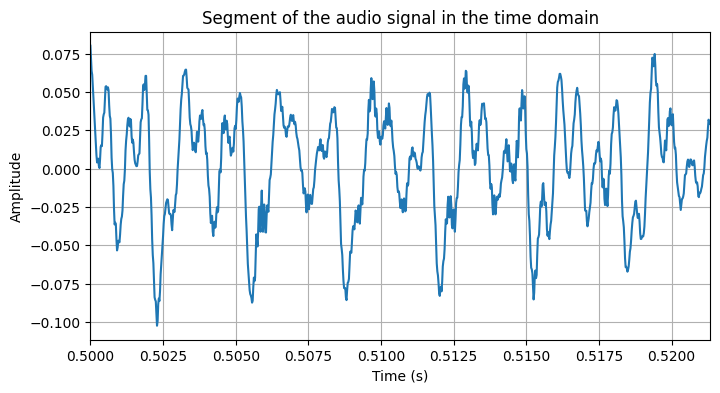

In [8]:
plt.figure(figsize=(8, 4))

# Plot of 1024 samples of the audio file
plt.plot(np.arange(fs//2, fs//2 + 1024)/fs, audio[fs//2 : fs//2 + 1024]) # Plot a segment of the audio signal, specifically 1024 samples starting from the middle of the audio file (fs//2). The x-axis is scaled to represent time in seconds by dividing the sample indices by the sampling rate (fs).
plt.xlim([fs//2/fs, (fs//2 + 1024)/fs]) # Set the x-axis limits to the range of the plotted segment, which corresponds to the time duration of the 1024 samples being plotted.
plt.grid(True)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Segment of the audio signal in the time domain')

The `difference()` function below calculates the difference between the squared signal and its delayed version for all the possible delay values $\tau$.

**/!\ Warning:** Don't use `difference()` but `difference_vectorized()` instead. It is much faster and has the same functionality, I only kept this one because it's easier to understand.

In [9]:
def difference(x, W, max_tau):
  diff = [0] * (max_tau + 1)
  for tau in range(max_tau + 1):
    for j in range(1, W - tau):
      diff[tau] += (x[j] - x[j + tau])**2
  return diff

In [10]:
def difference_vectorized(x, W, max_tau):
    diff = [0] * (max_tau + 1)
    for tau in range(max_tau + 1):
        diff[tau] = np.sum((x[1:W-tau] - x[1+tau:W])**2)
    return diff

(0.0, 960.0)

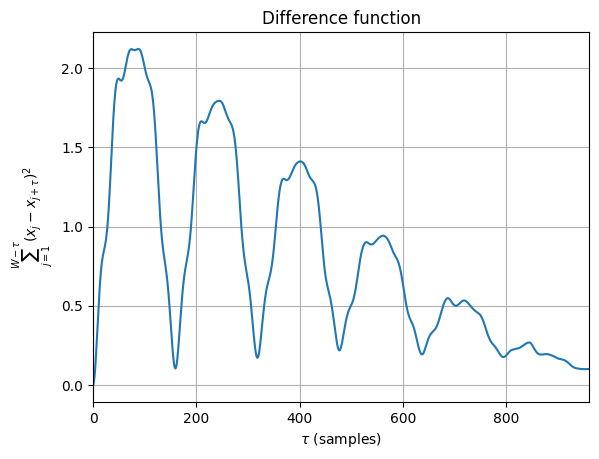

In [11]:
x = audio
max_tau = fs//50
plt.plot(difference_vectorized(x, 1024, max_tau))
plt.xlabel(r'$\tau$ (samples)')
plt.ylabel(r'$\sum_{j=1}^{W-\tau} (x_j - x_{j+\tau})^2$')
plt.title('Difference function')
plt.grid(True)
plt.xlim(0, max_tau)

The `computeCmndf()`  calculates the cmndf starting from the difference function.

In [12]:
# Function that calculates the cumulative mean normalized difference function.
def computeCmndf(x, W, min_tau, max_tau):
  cmndf = np.empty(max_tau - min_tau)
  diff = difference_vectorized(x, W, max_tau)
  for tau in range(min_tau, max_tau):
    if tau == 0:
      cmndf[tau - min_tau] = 1.0
    else:
      sum = np.sum(diff[1:tau+1])
      cmndf[tau - min_tau] = diff[tau] / (sum / tau)
  return cmndf

Predicted tau: 159.15 samples
Predicted fundamental frequency: 301.61 Hz


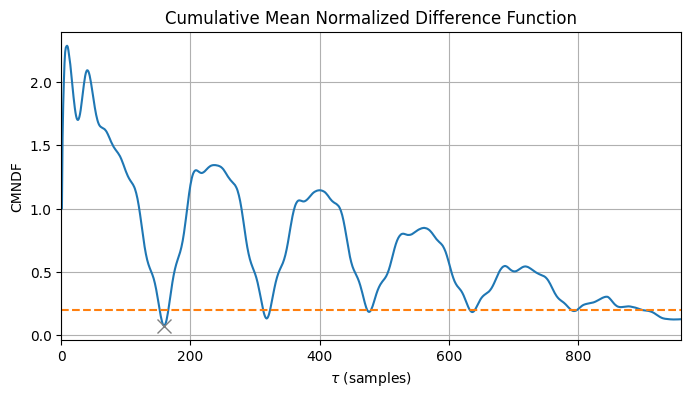

In [13]:
min_tau = 0
max_tau = fs//50
W = 1024

cmndf = computeCmndf(audio, W, min_tau, max_tau)
cmndf_threshold = 0.2

plt.figure(figsize=(8, 4))
plt.plot(cmndf)
plt.xlabel(r'$\tau$ (samples)')
plt.ylabel('CMNDF')
plt.title('Cumulative Mean Normalized Difference Function')
plt.grid(True)
plt.xlim([0, max_tau - min_tau])

predicted_tau = find_first_local_min_below_threshold(cmndf, cmndf_threshold)
plt.axhline(y=cmndf_threshold, color='C1', linestyle='--')
plt.plot(predicted_tau, cmndf[predicted_tau], 'xC7', markersize=10)

interp_add = parabolic_interp(cmndf[predicted_tau - 1], cmndf[predicted_tau], cmndf[predicted_tau + 1])
f0 = fs / (predicted_tau + interp_add)

print(f'Predicted tau: {predicted_tau + interp_add:.2f} samples')
print(f'Predicted fundamental frequency: {f0:.2f} Hz')

The function `pitchDetect()` below is going to be the main function that allows to estimate the pitch of a given audio signal. Frame by frame, it computes the CMNDF of the frame and finds the first candidate to f0 (a local minima from the CMNDF function) that falls below the stablished threshold. Only the values of $\tau$ corresponding to frequencies between `min_f0` and `max_f0` are considered.

In [14]:
def pitchDetect(audio, fs, min_f0, max_f0, W = 256, decimation_factor = 8, cmndf_threshold = 0.4):
  res = []

  downsampled_audio = sg.decimate(audio, decimation_factor, zero_phase=True)
  downsampled_fs = fs // decimation_factor

  min_tau = downsampled_fs // max_f0
  max_tau = downsampled_fs // min_f0

  length = (len(downsampled_audio) // (W//2) - 1) * (W//2)

  for start in tqdm(range(0, length , W//2), desc="Pitch estimation"):
    x = downsampled_audio[start:start+W]
    if (len(x) != W):
      break
    cmndf = computeCmndf(x, W, min_tau, max_tau)
    predicted_tau = find_first_local_min_below_threshold(cmndf, cmndf_threshold)
    if predicted_tau != None:
      interp_add = parabolic_interp(cmndf[predicted_tau - 1], cmndf[predicted_tau], cmndf[predicted_tau + 1])
      delay = min_tau + predicted_tau + interp_add
      f0 = downsampled_fs / delay
      res.append(f0)
    else:
      res.append(None)
  return np.array(res)

In [15]:
# Plot of the pitch estimation over the spectrogram
def plot_pitch_estimation(audio, fs, f0, min_f0, max_f0, decimation_factor = 8, W = 256, window_type = 'hamming'):
    downsampled_fs = fs // decimation_factor
    window = sg.get_window(window_type, W * decimation_factor)
    plt.rcParams.update({"axes.grid" : False})
    frequencies, times, spectrogram = sg.spectrogram(audio, fs, window = window)
    plt.figure(figsize=(8, 4))
    plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram))
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.colorbar(label='Power Spectral Density (dB)')
    plt.plot(np.arange(0, len(f0) * (W//2), (W//2))/downsampled_fs, f0)
    plt.ylim(min_f0, max_f0)
    plt.xlim(0, (len(f0) - 2) * (W//2) / downsampled_fs)

    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title('Spectrogram and pitch estimation of the input audio signal')

Next, I tested the pitch estimation algorithm in the input audio signal. The resulting pitch envelope over the original spectrogram is included below.

In [16]:
# Load the audio file and convert it to mono.
fs, audio = wavfile.read('Sounds/427200__thescarlettwitch89__female-ooh-singing-voice-cleaned-with-reverb-by-erokia.wav')
audio = audio[:,0]

C:\Users\lbennicoff1\AppData\Local\Temp\ipykernel_30792\1043792866.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, audio = wavfile.read('Sounds/427200__thescarlettwitch89__female-ooh-singing-voice-cleaned-with-reverb-by-erokia.wav')


Pitch estimation: 100%|██████████| 326/326 [00:00<00:00, 2413.76it/s]


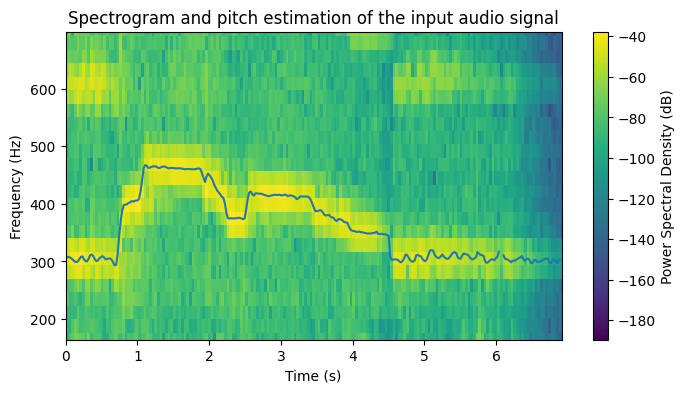

In [17]:
# Contralto voice range
min_f0 = int(np.floor(164.81)) # E3
max_f0 = int(np.ceil(698.46)) # E5

f0 = pitchDetect(audio, fs, min_f0, max_f0)
plot_pitch_estimation(audio, fs, f0, min_f0, max_f0)
ipd.Audio(audio, rate=fs)

In [18]:
# Load the audio file and convert it to mono.
fs, audio = wavfile.read('Sounds/367215__daalvinz__lalala.wav')
# There is silence at the end of the file, so we just keep the first 2 seconds.
audio = audio[:2*fs,0]

C:\Users\lbennicoff1\AppData\Local\Temp\ipykernel_30792\553409614.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, audio = wavfile.read('Sounds/367215__daalvinz__lalala.wav')


Pitch estimation: 100%|██████████| 92/92 [00:00<00:00, 673.50it/s]


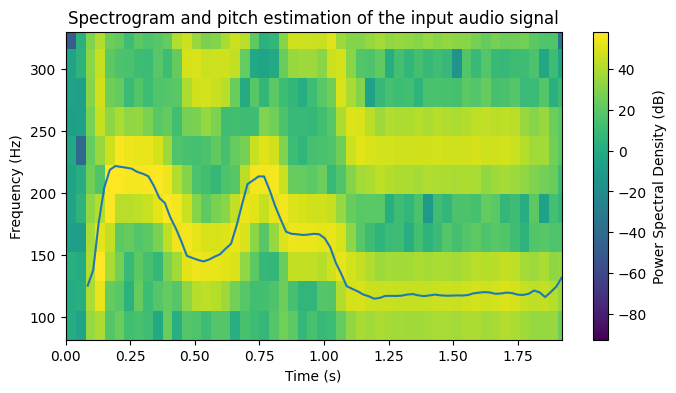

In [19]:
# Baritone vocal range
min_f0 = int(np.floor(82.41)) # E2
max_f0 = int(np.ceil(329.63)) # E4

f0 = pitchDetect(audio, fs, min_f0, max_f0)
plot_pitch_estimation(audio, fs, f0, min_f0, max_f0)
ipd.Audio(audio, rate=fs)

In [20]:
# Load the audio file. This one is already mono
fs, audio = wavfile.read('Sounds/30084__herbertboland__femalephrase1.wav')

Pitch estimation: 100%|██████████| 155/155 [00:00<00:00, 3535.42it/s]


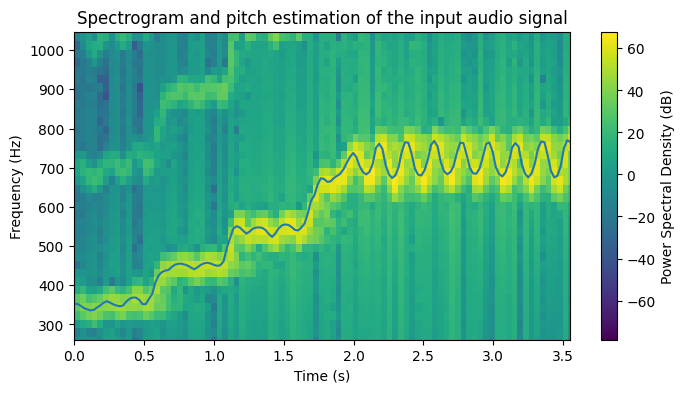

In [21]:
# Soprano vocal range
min_f0 = int(np.floor(261.63)) # C4
max_f0 = int(np.ceil(1046.50)) # C6

f0 = pitchDetect(audio, fs, min_f0, max_f0)
plot_pitch_estimation(audio, fs, f0, min_f0, max_f0)
ipd.Audio(audio, rate=fs)

In [22]:
# Load the audio file. This one is already mono
fs, audio = wavfile.read('Sounds/417938__thescarlettwitch89__do-you-wanna-be-beautiful-vocal-sample-1.wav')
audio = audio[int(0.5*fs):]

Pitch estimation: 100%|██████████| 166/166 [00:00<00:00, 3258.61it/s]


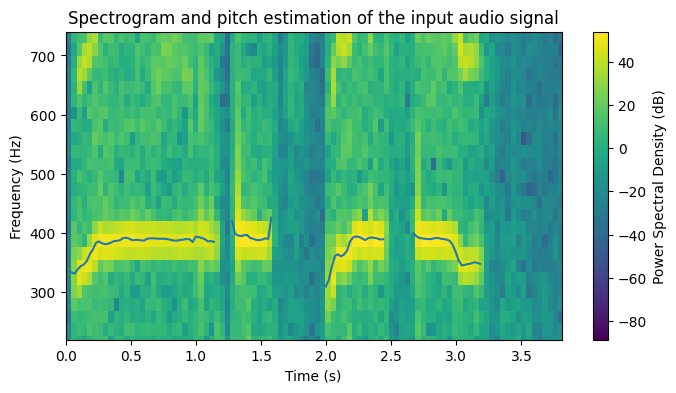

In [23]:
# Mezzo soprano vocal range
min_f0 = int(np.floor(220.00)) # A3
max_f0 = int(np.ceil(739.99)) # F5

f0 = pitchDetect(audio, fs, min_f0, max_f0)
plot_pitch_estimation(audio, fs, f0, min_f0, max_f0)
ipd.Audio(audio, rate=fs)